# Exploratory Data Analysis & Feature Engineering
### Steel Industry Energy Consumption Dataset

**Objective:** Investigate the steel plant energy dataset through deep EDA, engineer new
features from existing columns, and identify data quality issues that could affect
model training later in `modeling.ipynb`.

**Dataset source:** UCI Machine Learning Repository — Steel Industry Energy Consumption
(https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption)

**Structure of this notebook:**
1. Load data & inspect structure
2. Datetime feature engineering (hour, day of week, month, weekday/weekend)
3. `Power_Factor_Ratio` feature
4. `High_Usage_Flag` binary feature
5. Outlier detection in `Usage_kWh` (IQR method) + boxplot
6. Correlation heatmap + top correlated features
7. Average energy consumption by Load Type (bar chart)
8. Average energy usage by hour of day (line chart)
9. EDA Summary (written conclusions)


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

RAW_DATA_PATH = "../Data/Steel_industry_data.csv"
PROCESSED_DATA_PATH = "../Data/Steel_industry_data_engineered.csv"


## 2. Load Dataset & Re-examine Structure

We load the raw CSV and take a first look at shape, dtypes, missing values,
duplicates, and summary statistics before touching anything.

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Duplicate rows: 0


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,35040,35040,01/01/2018 00:15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Usage_kWh,35040.0,NaN,NaN,NaN,27.386892,33.44438,0.0,3.2,4.57,51.2375,157.18
Lagging_Current_Reactive.Power_kVarh,35040.0,NaN,NaN,NaN,13.035384,16.306,0.0,2.3,5.0,22.64,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,NaN,NaN,NaN,3.870949,7.424463,0.0,0.0,0.0,2.09,27.76
CO2(tCO2),35040.0,NaN,NaN,NaN,0.011524,0.016151,0.0,0.0,0.0,0.02,0.07
Lagging_Current_Power_Factor,35040.0,NaN,NaN,NaN,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.0
Leading_Current_Power_Factor,35040.0,NaN,NaN,NaN,84.36787,30.456535,0.0,99.7,100.0,100.0,100.0
NSM,35040.0,NaN,NaN,NaN,42750.0,24940.534317,0.0,21375.0,42750.0,64125.0,85500.0
WeekStatus,35040,2,Weekday,25056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_week,35040,7,Monday,5088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Datetime Feature Engineering

Convert the `date` column to a proper `datetime` dtype, then extract:
- `Hour` — hour of day (0–23)
- `DayOfWeek` — name of the day (e.g. Monday)
- `Month` — calendar month (1–12)
- `Is_Weekend` — 1 if Saturday/Sunday, else 0

In [6]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["Hour"] = df["date"].dt.hour
df["DayOfWeek"] = df["date"].dt.day_name()
df["Month"] = df["date"].dt.month
df["Is_Weekend"] = df["date"].dt.dayofweek.isin([5, 6]).astype(int)

df[["date", "Hour", "DayOfWeek", "Month", "Is_Weekend"]].head()


,date,Hour,DayOfWeek,Month,Is_Weekend
0,2018-01-01 00:15:00,0,Monday,1,0
1,2018-01-01 00:30:00,0,Monday,1,0
2,2018-01-01 00:45:00,0,Monday,1,0
3,2018-01-01 01:00:00,1,Monday,1,0
4,2018-01-01 01:15:00,1,Monday,1,0


**Data quality note — redundant columns:** the raw dataset already ships
with `Day_of_week` and `WeekStatus` columns containing the same information as
the `DayOfWeek` and `Is_Weekend` columns just engineered from `date`. Keeping
both copies creates perfectly collinear (duplicate) features — harmless for
tree-based models, but it breaks the stability/interpretability of linear
models (Linear Regression, Ridge) due to multicollinearity. We drop the
original raw versions and keep the `date`-derived versions going forward.

In [7]:
df = df.drop(columns=["Day_of_week", "WeekStatus"])
print("Remaining columns:", list(df.columns))


Remaining columns: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Load_Type', 'Hour', 'DayOfWeek', 'Month', 'Is_Weekend']


## 4. `Power_Factor_Ratio` Feature

Defined as **Leading Current Power Factor ÷ Lagging Current Power Factor**.
This ratio captures the balance between leading and lagging power factor
readings — useful since both individually relate to electrical efficiency.

In [8]:
# Guard against division by zero
df["Power_Factor_Ratio"] = df["Leading_Current_Power_Factor"] / df["Lagging_Current_Power_Factor"].replace(0, np.nan)

df[["Leading_Current_Power_Factor", "Lagging_Current_Power_Factor", "Power_Factor_Ratio"]].head()


,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio
0,100.0,73.21,1.365934
1,100.0,66.77,1.497679
2,100.0,70.28,1.422880
3,100.0,68.09,1.468644
4,100.0,64.72,1.545117


## 5. `High_Usage_Flag` Binary Feature

Flags rows where `Usage_kWh` is above the **75th percentile** as `1`, else `0`.


In [9]:
usage_p75 = df["Usage_kWh"].quantile(0.75)
df["High_Usage_Flag"] = (df["Usage_kWh"] > usage_p75).astype(int)

print(f"75th percentile of Usage_kWh: {usage_p75:.2f} kWh")
print(df["High_Usage_Flag"].value_counts())


75th percentile of Usage_kWh: 51.24 kWh
High_Usage_Flag
0    26280
1     8760
Name: count, dtype: int64


## 6. Outlier Detection in `Usage_kWh` (IQR Method)

We use the standard Interquartile Range (IQR) rule:
a value is an outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [10]:
Q1 = df["Usage_kWh"].quantile(0.25)
Q3 = df["Usage_kWh"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Usage_kWh"] < lower_bound) | (df["Usage_kWh"] > upper_bound)]
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Lower bound={lower_bound:.2f}, Upper bound={upper_bound:.2f}")
print(f"Number of outliers detected in Usage_kWh: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of rows)")


Q1=3.20, Q3=51.24, IQR=48.04
Lower bound=-68.86, Upper bound=123.29
Number of outliers detected in Usage_kWh: 328 (0.94% of rows)


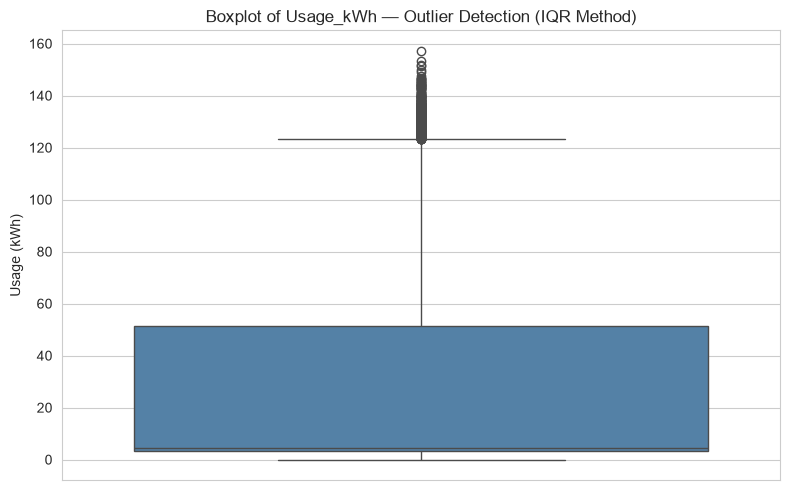

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df["Usage_kWh"], color="steelblue", ax=ax)
ax.set_title("Boxplot of Usage_kWh — Outlier Detection (IQR Method)")
ax.set_ylabel("Usage (kWh)")
plt.tight_layout()
plt.show()


## 7. Correlation Heatmap

Correlation across all numerical features, with a focus on which features
correlate most strongly with the target, `Usage_kWh`.

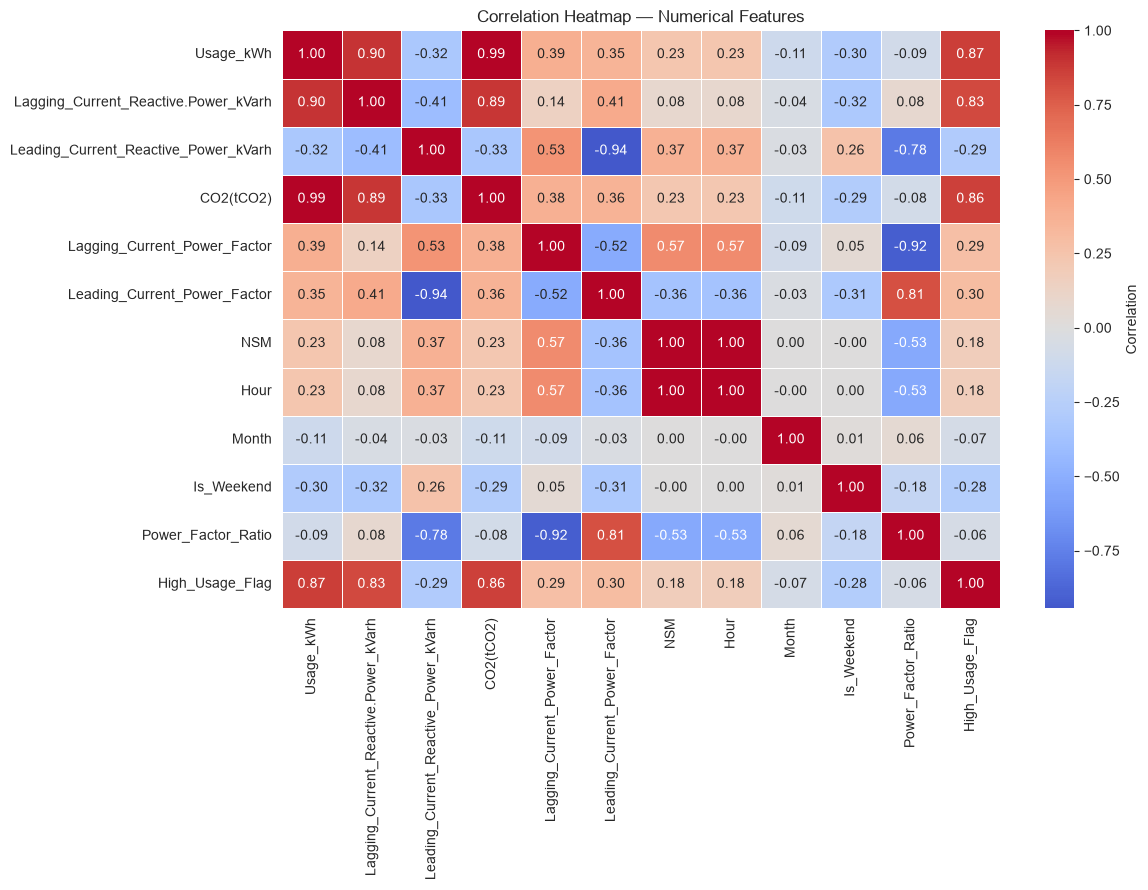

In [12]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()


In [13]:
usage_corr = corr_matrix["Usage_kWh"].drop("Usage_kWh").sort_values(key=lambda s: s.abs(), ascending=False)
print("Features ranked by absolute correlation with Usage_kWh:")
print(usage_corr)

top3 = usage_corr.head(3)
print("\nTop 3 features most correlated with Usage_kWh:")
print(top3)


Features ranked by absolute correlation with Usage_kWh:
CO2(tCO2)                               0.988180
Lagging_Current_Reactive.Power_kVarh    0.896150
High_Usage_Flag                         0.867840
Lagging_Current_Power_Factor            0.385960
Leading_Current_Power_Factor            0.353566
Leading_Current_Reactive_Power_kVarh   -0.324922
Is_Weekend                             -0.295475
NSM                                     0.234610
Hour                                    0.234175
Month                                  -0.113961
Power_Factor_Ratio                     -0.090094
Name: Usage_kWh, dtype: float64

Top 3 features most correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
High_Usage_Flag                         0.86784
Name: Usage_kWh, dtype: float64


## 8. Average Energy Consumption by Load Type

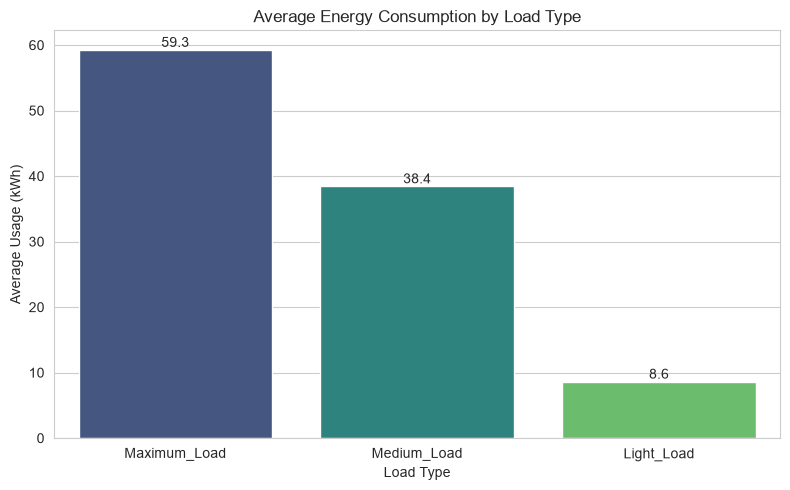

In [14]:
load_avg = df.groupby("Load_Type")["Usage_kWh"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=load_avg.index, y=load_avg.values, hue=load_avg.index, palette="viridis", legend=False)
plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")
for i, v in enumerate(load_avg.values):
    plt.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 9. Average Energy Usage by Hour of Day

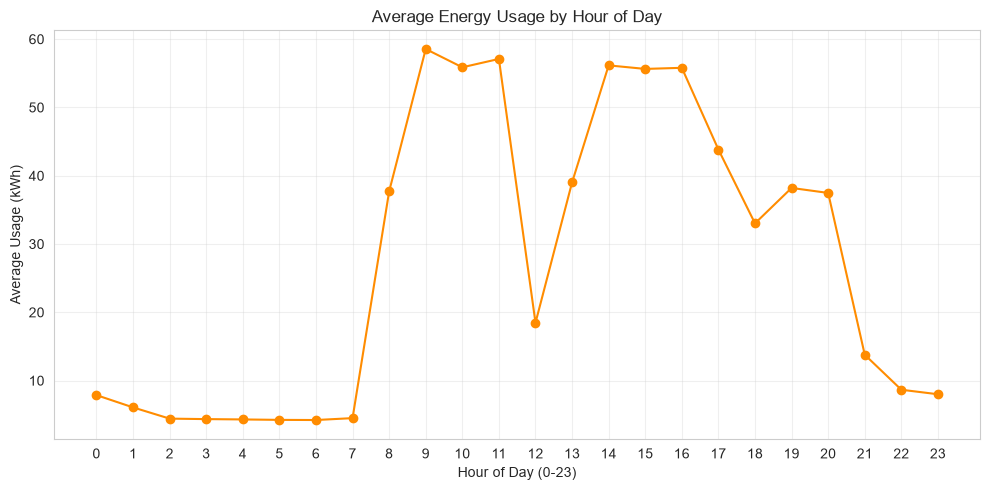

In [15]:
hourly_avg = df.groupby("Hour")["Usage_kWh"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o", color="darkorange")
plt.title("Average Energy Usage by Hour of Day")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Average Usage (kWh)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Save Engineered Dataset

Save the dataframe with all new features so (`modeling.ipynb`)
can load it directly without repeating the feature engineering steps.

In [16]:
df.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Engineered dataset saved to: {PROCESSED_DATA_PATH}")
print("Final shape:", df.shape)
print("Columns:", list(df.columns))


Engineered dataset saved to: ../Data/Steel_industry_data_engineered.csv
Final shape: (35040, 15)
Columns: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Load_Type', 'Hour', 'DayOfWeek', 'Month', 'Is_Weekend', 'Power_Factor_Ratio', 'High_Usage_Flag']


## 10. EDA Summary 

**Data quality issues found:** The raw dataset (35,040 rows, 15 columns,
covering a full year at 15-minute intervals) turned out to be very clean —
`df.isnull().sum()` showed **zero missing values** across all columns and
`df.duplicated().sum()` showed **zero duplicate rows**, so no rows needed to
be dropped before feature engineering. The one real quality issue is in the
IQR outlier check: `Usage_kWh` is heavily right-skewed (median 4.57 kWh vs.
mean 27.4 kWh), so the IQR method flagged **328 rows (0.94%)** as outliers,
all on the high side (the computed lower bound was negative, which is
meaningless for a non-negative energy reading, so effectively only the upper
tail is being flagged). These high values line up with `Maximum_Load`
periods rather than sensor errors, so they were kept, not removed.

**Top correlated features:** `Usage_kWh` correlates almost perfectly with
`CO2(tCO2)` (r = 0.99) and strongly with `Lagging_Current_Reactive.Power_kVarh`
(r = 0.90) — both scale directly with active electrical load, so this is
expected. `High_Usage_Flag` also shows a high correlation (r = 0.87), but
that's because it was engineered directly from `Usage_kWh` (target leakage),
so it doesn't count as an independent feature — the next genuine driver is
`Lagging_Current_Power_Factor` (r = 0.39).

**Most interesting pattern:** Usage follows a strong double-hump daily
cycle — near-zero overnight (hours 0–7, ~4–8 kWh), a sharp jump at hour 8
(~38 kWh) peaking around hours 9–11 (~56–58 kWh), a sharp lunchtime dip at
hour 12 (~18.6 kWh), a second peak from hours 13–16, then a steady decline
into the evening. `Maximum_Load` periods average **59.3 kWh** vs. **38.4**
for `Medium_Load` and just **8.6** for `Light_Load`.

**Hypothesis on energy spikes:** Spikes are schedule-driven, not random —
they align with production shifts running `Maximum_Load` operations during
working hours, with the midday dip suggesting a shutdown/break window between
morning and afternoon shifts.
